# Load dataset

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('clean_data.csv')

# Split data

## Original data

In [3]:
#Split the original data into features and target
from sklearn.model_selection import train_test_split

X = df.drop('classification',axis=1)
y = df['classification']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=10, stratify=y)

## Feature selection

### Filter method : correlation-based feature selection

In [4]:
import time

start = time.time()
correlation_matrix = df.corr()
correlation = correlation_matrix['classification'].sort_values(ascending=False)
cor_index = list((correlation.index[index]) for index, attr in enumerate(correlation) if abs(attr) >= 0.5)
X_column_corr = cor_index

end = time.time()

print(f"Duration for Filter method is {round(end-start,5)} sec")

Duration for Filter method is 0.00629 sec


In [5]:
correlation_matrix['classification'].sort_values(ascending=False)

classification    1.000000
htn               0.590438
dm                0.559060
sc                0.547624
al                0.531562
bgr               0.401374
pe                0.375154
bu                0.372033
ane               0.325396
su                0.294555
bp                0.290600
pcc               0.265313
cad               0.236088
age               0.225405
wc                0.205274
ba                0.186871
pot               0.028406
rbc              -0.282642
pc               -0.375154
appet            -0.393341
sod              -0.463721
rc               -0.590913
sg               -0.659504
pcv              -0.690060
hemo             -0.729628
Name: classification, dtype: float64

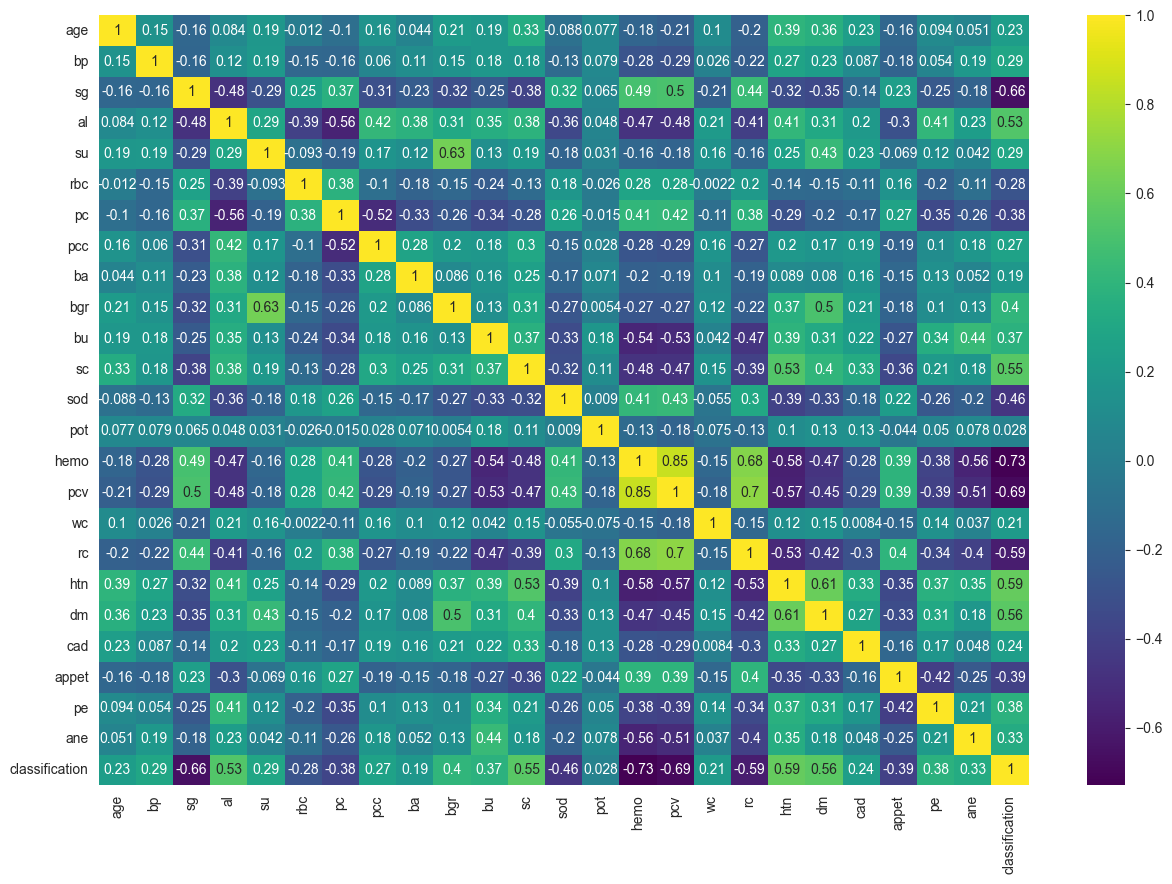

In [6]:
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix, annot=True, cmap = 'viridis')
plt.savefig("Correlation of classification")
plt.show()

In [7]:
filter_data = df[X_column_corr]
filter_data

,classification,htn,dm,sc,al,rc,sg,pcv,hemo
0,1,1,1,-0.395962,1.0,5.869015e-01,1.020,0.628372,1.059271
1,1,0,0,-0.801232,4.0,-1.058283e-15,1.020,-0.108649,-0.452097
2,1,0,1,0.211943,2.0,-1.058283e-15,1.010,-0.968506,-1.078762
3,1,1,0,2.238293,4.0,-9.620758e-01,1.005,-0.845669,-0.488960
4,1,0,0,-0.193327,2.0,-1.280111e-01,1.010,-0.477159,-0.341509
...,...,...,...,...,...,...,...,...,...
395,0,0,0,-1.105185,0.0,2.294455e-01,1.020,0.996882,1.169859
396,0,0,0,-0.395962,0.0,1.778423e+00,1.025,1.856739,1.464760
397,0,0,0,-1.003867,0.0,8.252061e-01,1.020,1.242555,1.206722
398,0,0,0,-0.598597,0.0,1.420967e+00,1.025,1.488229,0.616920


In [8]:
print('Filter method selected features are',len(X_column_corr[1:]),':',X_column_corr[1:])

Filter method selected features are 8 : ['htn', 'dm', 'sc', 'al', 'rc', 'sg', 'pcv', 'hemo']


### Wrapper method : Stepwise method

In [9]:
#import library
from sklearn.ensemble import RandomForestClassifier
#pip install mlxtend #if you use mlxtend first time.
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [10]:
rf = RandomForestClassifier(random_state=0)

start = time.time()
# Initialize the SequentialFeatureSelector
sfs = SFS(rf,
          k_features='best',  # Select the best subset of features
          forward=True,        # Forward selection
          floating=True,       # Backward selection
          scoring='accuracy',
          cv=5)

# Fit the SFS on your data
sfs = sfs.fit(X, y)

# Get the selected feature indices

selected_features = list(sfs.k_feature_idx_)
selected_columns = df.columns[list(sfs.k_feature_idx_)+ [len(df.columns) - 1]]

end = time.time()

print("Duration for Wrapper method is",round(end-start,5),"sec")

Duration for Wrapper method is 694.51951 sec


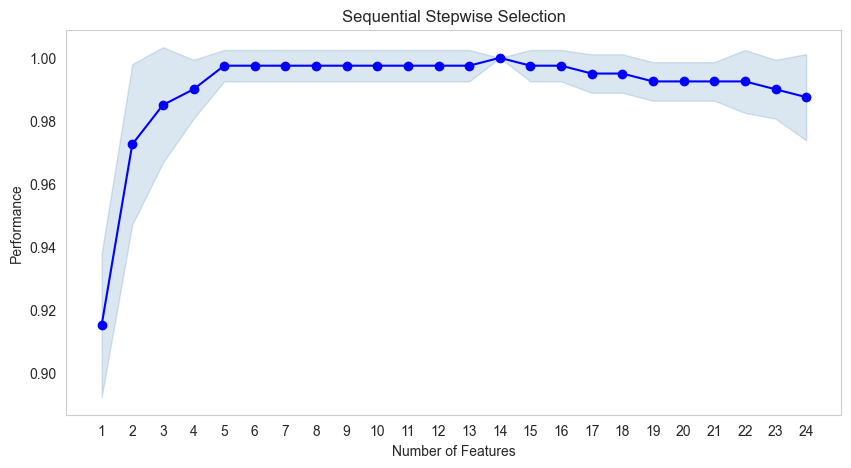

In [11]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

wrap = plot_sfs(sfs.get_metric_dict(), figsize=(10,5))
plt.title('Sequential Stepwise Selection')
plt.grid()
plt.savefig('SFS_.png')
plt.show()

In [32]:
pd.DataFrame(sfs.get_metric_dict())

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
feature_idx,"(14,)","(2, 14)","(2, 3, 14)","(2, 3, 11, 14)","(2, 3, 5, 11, 14)","(2, 3, 5, 11, 14, 18)","(2, 3, 4, 5, 11, 14, 18)","(0, 2, 3, 4, 5, 11, 14, 18)","(2, 3, 4, 5, 6, 7, 11, 14, 18)","(2, 3, 4, 5, 6, 7, 8, 11, 14, 18)",...,"(0, 2, 3, 4, 5, 6, 7, 8, 11, 14, 18, 19, 20, 2...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 14, 18, 19, 20...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 14, 15, 18, 19...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 14, 15, 18, 19...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 14, 15, 18...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
cv_scores,"[0.9375, 0.8875, 0.8875, 0.925, 0.9375]","[0.975, 1.0, 0.925, 0.9875, 0.975]","[0.9875, 1.0, 0.95, 0.9875, 1.0]","[0.9875, 1.0, 0.975, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]",...,"[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 1.0, 0.9875, 1.0]","[1.0, 1.0, 0.9875, 0.9875, 1.0]","[1.0, 1.0, 0.9875, 0.9875, 1.0]","[0.9875, 1.0, 0.9875, 0.9875, 1.0]","[0.9875, 1.0, 0.9875, 0.9875, 1.0]","[0.9875, 1.0, 0.9875, 0.9875, 1.0]","[1.0, 1.0, 0.9875, 0.975, 1.0]","[0.9875, 1.0, 0.975, 0.9875, 1.0]","[0.9875, 1.0, 0.9625, 0.9875, 1.0]"
avg_score,0.915,0.9725,0.985,0.99,0.9975,0.9975,0.9975,0.9975,0.9975,0.9975,...,0.9975,0.9975,0.995,0.995,0.9925,0.9925,0.9925,0.9925,0.99,0.9875
feature_names,"(hemo,)","(sg, hemo)","(sg, al, hemo)","(sg, al, sc, hemo)","(sg, al, rbc, sc, hemo)","(sg, al, rbc, sc, hemo, htn)","(sg, al, su, rbc, sc, hemo, htn)","(age, sg, al, su, rbc, sc, hemo, htn)","(sg, al, su, rbc, pc, pcc, sc, hemo, htn)","(sg, al, su, rbc, pc, pcc, ba, sc, hemo, htn)",...,"(age, sg, al, su, rbc, pc, pcc, ba, sc, hemo, ...","(age, bp, sg, al, su, rbc, pc, pcc, ba, sc, he...","(age, bp, sg, al, su, rbc, pc, pcc, ba, sc, he...","(age, bp, sg, al, su, rbc, pc, pcc, ba, sc, he...","(age, bp, sg, al, su, rbc, pc, pcc, ba, sc, so...","(age, bp, sg, al, su, rbc, pc, pcc, ba, sc, so...","(age, bp, sg, al, su, rbc, pc, pcc, ba, sc, so...","(age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, b...","(age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, b...","(age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, b..."
ci_bound,0.02945,0.032769,0.023612,0.012023,0.006426,0.006426,0.006426,0.006426,0.006426,0.006426,...,0.006426,0.006426,0.007871,0.007871,0.007871,0.007871,0.007871,0.012853,0.012023,0.0176
std_dev,0.022913,0.025495,0.018371,0.009354,0.005,0.005,0.005,0.005,0.005,0.005,...,0.005,0.005,0.006124,0.006124,0.006124,0.006124,0.006124,0.01,0.009354,0.013693
std_err,0.011456,0.012748,0.009186,0.004677,0.0025,0.0025,0.0025,0.0025,0.0025,0.0025,...,0.0025,0.0025,0.003062,0.003062,0.003062,0.003062,0.003062,0.005,0.004677,0.006847


In [13]:
wrapper_data = df[selected_columns]

,age,sg,al,su,rbc,pc,pcc,ba,hemo,htn,dm,cad,appet,pe,classification
0,-0.205464,1.020,1.0,0.0,1,1,0,0,1.059271,1,1,0,1,0,1
1,-2.623810,1.020,4.0,0.0,1,1,0,0,-0.452097,0,0,0,1,0,1
2,0.620313,1.010,2.0,3.0,1,1,0,0,-1.078762,0,1,0,0,0,1
3,-0.205464,1.005,4.0,0.0,1,0,1,0,-0.488960,1,0,0,0,1,1
4,-0.028511,1.010,2.0,0.0,1,1,0,0,-0.341509,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.207425,1.020,0.0,0.0,1,1,0,0,1.169859,0,0,0,1,0,0
396,-0.559368,1.025,0.0,0.0,1,1,0,0,1.464760,0,0,0,1,0,0
397,-2.328890,1.020,0.0,0.0,1,1,0,0,1.206722,0,0,0,1,0,0
398,-2.033969,1.025,0.0,0.0,1,1,0,0,0.616920,0,0,0,1,0,0


In [14]:
print('Wrapper method selected features are',len(selected_features),':',selected_columns.drop('classification'))

Wrapper method selected features are 14 : Index(['age', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'hemo', 'htn', 'dm',
       'cad', 'appet', 'pe'],
      dtype='object')


### Embbed method : Rain forest

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
start = time.time()
#fit the model
rf.fit(X, y)

# get feature importance scores
importance = rf.feature_importances_

# create a DataFrame to store feature importance scores
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# sort the features by importance score in descending order
feature_importance = pd.Series(importance, index=X.columns)

num_features = list(range(1, len(df.columns)))
accuracy = []

for i in num_features:
    top_idx = feature_importance.sort_values(ascending=False)[:i].index
    X_train_i, X_test_i = X_train[top_idx], X_test[top_idx]
    accuracy.append(accuracy_score(y_test, rf.fit(X_train_i, y_train).predict(X_test_i)))

optimal_num = num_features[accuracy.index(max(accuracy))]
top_idx = feature_importance.sort_values(ascending=False)[:optimal_num].index

end = time.time()

print("Duration for Embed method is",round(end-start,7),"sec")

Duration for Embed method is 6.4274735 sec


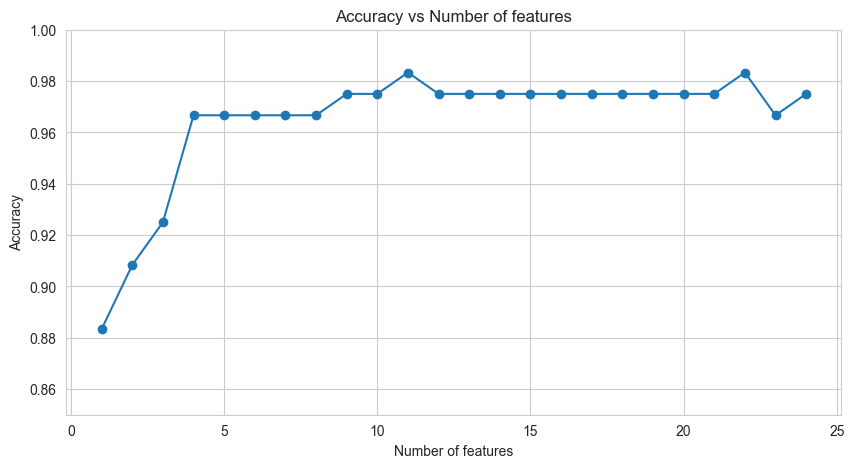

Maximum accuracy is 0.983 at  11 features


In [17]:
# Plot the results
plt.figure(figsize=(10,5))
plt.plot(num_features, accuracy,marker='o')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.ylim(0.85,1)
plt.title('Accuracy vs Number of features')
plt.savefig("Embbed_acc_.png")
plt.show()
print("Maximum accuracy is",round(max(accuracy),3),"at ",optimal_num,"features")

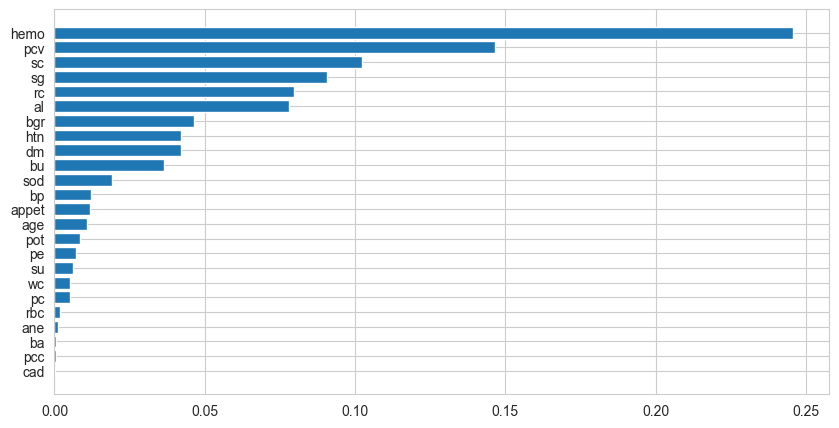

In [18]:
import matplotlib.pyplot as plt
feature_order = feature_importance.sort_values(ascending=False).sort_values()

plt.figure(figsize = (10,5))
plt.barh(feature_order.index, feature_order.values)
plt.savefig("feature_importance_embed.png")
plt.show()

In [19]:
embbed_data = df[top_idx.append(pd.Index(['classification']))]

In [20]:
print('Embbed method selected features are',len(top_idx),':',top_idx)

Embbed method selected features are 11 : Index(['hemo', 'pcv', 'sc', 'sg', 'rc', 'al', 'bgr', 'htn', 'dm', 'bu', 'sod'], dtype='object')


# Train model

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score,precision_score,f1_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

models = [
    ('LR', LogisticRegression()),
    ('SVM', SVC(gamma='auto')),
    ('Naive', GaussianNB()),
    ('KNN', KNeighborsClassifier(n_neighbors=2))
]

datasets = {
    'without_fs': df,
    'filter_data': filter_data,
    'wrapper_data': wrapper_data,
    'embbed_data': embbed_data
}

# Open a file in write mode to save the results
with open('classification_reports.txt', 'w') as f:
    length_time = {}
    train_accuracy_fs = {}
    accuracy_fs = {}
    precision_fs = {}
    f1_fs = {}
    recall_fs = {}
    for dataset_name, dataset in datasets.items():
        print(f"Current Dataset: {dataset_name}", file=f)

        X = dataset.drop('classification', axis=1)
        y = dataset['classification']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50,stratify=y)


        for model_name, model in models:
            model.fit(X_train, y_train)
            print(f"Model: {model_name}", file=f)

            # Training data
            start = time.time()
            y_train_pred = model.predict(X_train)
            end = time.time()
            duration = end-start
            train_report = classification_report(y_train, y_train_pred)
            train_accuracy = balanced_accuracy_score(y_train,y_train_pred)

            train_accuracy_fs[dataset_name,model_name] = round(train_accuracy*100,2)
            print("Train Classification Report:", file=f)
            print(f"The duration of train data:{round(duration,5)} sec", file=f)
            print(train_report, file=f)
            print(train_report)


            # Test data
            start = time.time()
            y_test_pred = model.predict(X_test)
            end = time.time()
            duration = end-start

            test_report = classification_report(y_test, y_test_pred)
            test_accuracy = balanced_accuracy_score(y_test,y_test_pred)
            test_precision = precision_score(y_test,y_test_pred)
            test_f1 = f1_score(y_test,y_test_pred)
            test_recall = recall_score(y_test,y_test_pred)

            length_time[dataset_name,model_name] = round(duration,5)
            accuracy_fs[dataset_name,model_name] = round(test_accuracy*100,2)
            precision_fs[dataset_name,model_name] = round(test_precision*100,2)
            f1_fs[dataset_name,model_name] = round(test_f1*100,2)
            recall_fs[dataset_name,model_name] = round(test_recall*100,2)


            print("Test Classification Report:", file=f)
            print(f"The duration of test data:{round(duration,5)} sec",file=f)
            print(test_report, file=f)
            print(test_report)
            print(f"The duration of test data:{round(duration,5)} sec")

            print("=" * 40, file=f)

        print("=" * 60, file=f)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       105
           1       0.99      0.98      0.99       175

    accuracy                           0.98       280
   macro avg       0.98      0.98      0.98       280
weighted avg       0.98      0.98      0.98       280

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      0.99      0.99        75

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

The duration of test data:0.003 sec
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       105
           1       0.99      0.98      0.99       175

    accuracy                           0.98       280
   macro avg       0.98      0.98      0.98       280
weighted avg       0.98      0.98     

# Visualise result

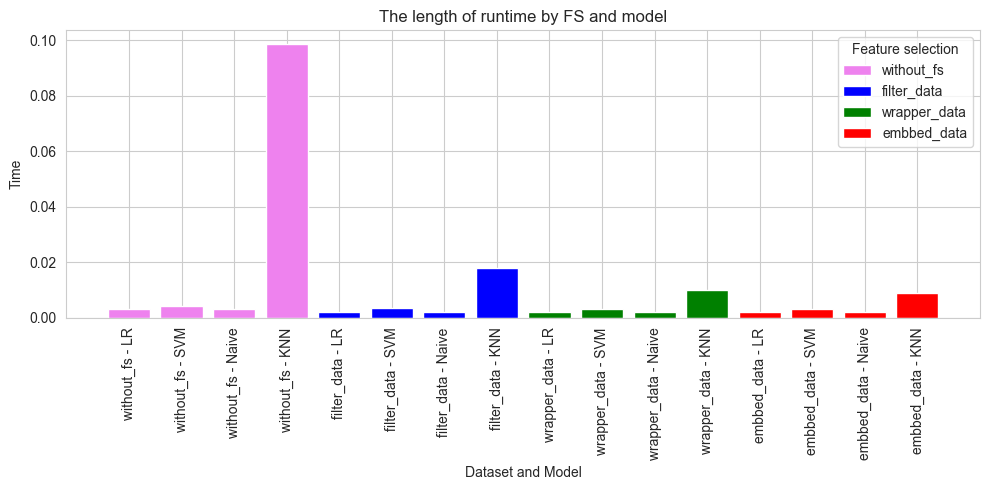

In [24]:
keys = [f"{key[0]} - {key[1]}" for key in length_time.keys()]
values = list(length_time.values())

# Group keys and values by key[0]
data_dict = {}
for key, value in zip(keys, values):
    key0 = key.split(' - ')[0]
    if key0 not in data_dict:
        data_dict[key0] = {'keys': [], 'values': []}
    data_dict[key0]['keys'].append(key)
    data_dict[key0]['values'].append(value)

# Create a bar plot for each group
plt.figure(figsize=(10, 5))
colors = ['violet', 'blue', 'green', 'red']  # You can add more colors if needed

for i, (key0, data) in enumerate(data_dict.items()):
    plt.bar(data['keys'], data['values'], color=colors[i], label=key0)

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("Time")
plt.title("The length of runtime by FS and model")

# Display the plot
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Feature selection", loc="upper right")  # Add a legend for the groups
plt.savefig('LOT by FS and Model')
plt.show()


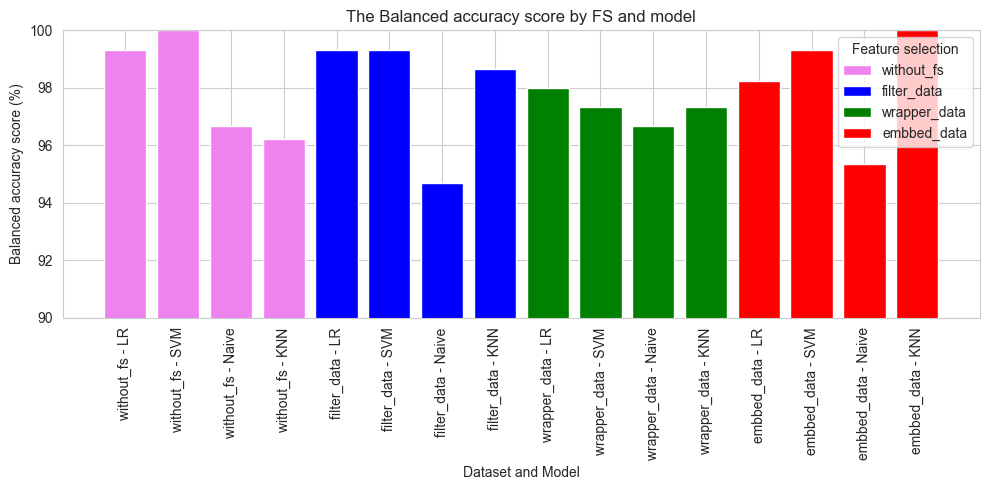

In [25]:
ba_keys = [f"{key[0]} - {key[1]}" for key in accuracy_fs.keys()]
ba_values = list(accuracy_fs.values())

# Group keys and values by key[0]
data_dict = {}
for key, value in zip(ba_keys, ba_values):
    key0 = key.split(' - ')[0]
    if key0 not in data_dict:
        data_dict[key0] = {'keys': [], 'values': []}
    data_dict[key0]['keys'].append(key)
    data_dict[key0]['values'].append(value)

# Create a bar plot for each group
plt.figure(figsize=(10, 5))
colors = ['violet', 'blue', 'green', 'red']  # You can add more colors if needed

for i, (key0, data) in enumerate(data_dict.items()):
    plt.bar(data['keys'], data['values'], color=colors[i], label=key0)

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("Balanced accuracy score (%)")
plt.ylim(90, 100)
plt.title("The Balanced accuracy score by FS and model")

# Display the plot
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Feature selection", loc="upper right")  # Add a legend for the groups
plt.savefig('ba_accuracy by FS and Model')
plt.show()

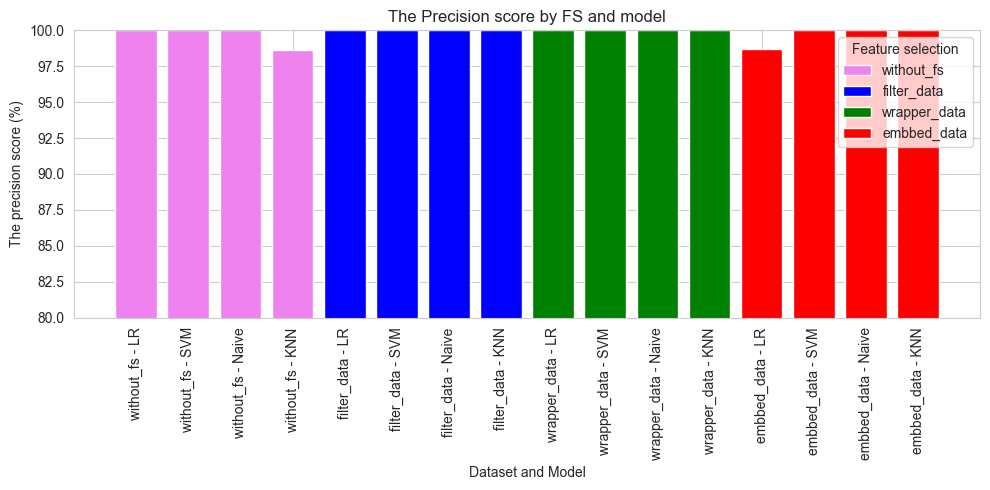

In [26]:
ps_keys = [f"{key[0]} - {key[1]}" for key in precision_fs.keys()]
ps_values = list(precision_fs.values())

# Group keys and values by key[0]
data_dict = {}
for key, value in zip(ps_keys, ps_values):
    key0 = key.split(' - ')[0]
    if key0 not in data_dict:
        data_dict[key0] = {'keys': [], 'values': []}
    data_dict[key0]['keys'].append(key)
    data_dict[key0]['values'].append(value)

# Create a bar plot for each group
plt.figure(figsize=(10, 5))
colors = ['violet', 'blue', 'green', 'red']


for i, (key0, data) in enumerate(data_dict.items()):
    plt.bar(data['keys'], data['values'], color=colors[i], label=key0)

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("The precision score (%)")
plt.ylim(80, 100)
plt.title("The Precision score by FS and model")

# Display the plot
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Feature selection", loc="upper right")
plt.savefig('precision by FS and Model')
plt.show()

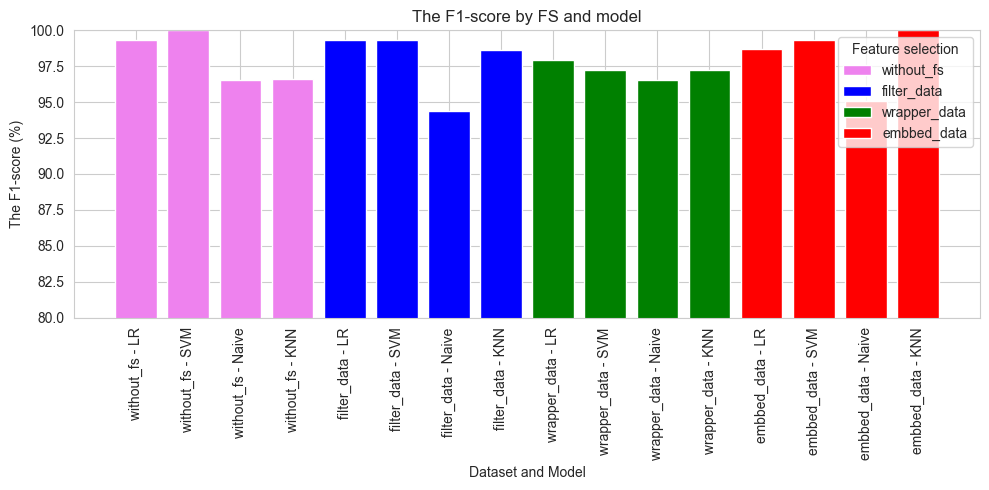

In [27]:
import matplotlib.pyplot as plt

# Your keys and values
f1_keys = [f"{key[0]} - {key[1]}" for key in f1_fs.keys()]
f1_values = list(f1_fs.values())

# Group keys and values by key[0]
data_dict = {}
for key, value in zip(f1_keys, f1_values):
    key0 = key.split(' - ')[0]
    if key0 not in data_dict:
        data_dict[key0] = {'keys': [], 'values': []}
    data_dict[key0]['keys'].append(key)
    data_dict[key0]['values'].append(value)

# Create a bar plot for each group
plt.figure(figsize=(10, 5))
colors = ['violet', 'blue', 'green', 'red']

for i, (key0, data) in enumerate(data_dict.items()):
    plt.bar(data['keys'], data['values'], color=colors[i], label=key0)

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("The F1-score (%)")
plt.ylim(80, 100)
plt.title("The F1-score by FS and model")

# Display the plot
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Feature selection", loc="upper right")
plt.savefig('f1 by FS and Model')
plt.show()

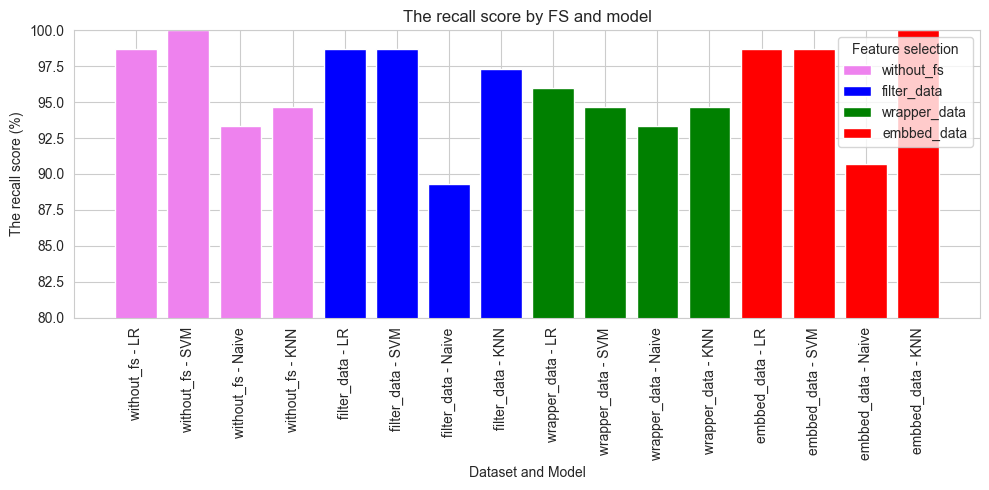

In [28]:
recall_keys = [f"{key[0]} - {key[1]}" for key in recall_fs.keys()]
recall_values = list(recall_fs.values())

# Group keys and values by key[0]
data_dict = {}
for key, value in zip(recall_keys, recall_values):
    key0 = key.split(' - ')[0]
    if key0 not in data_dict:
        data_dict[key0] = {'keys': [], 'values': []}
    data_dict[key0]['keys'].append(key)
    data_dict[key0]['values'].append(value)

# Create a bar plot for each group
plt.figure(figsize=(10, 5))
colors = ['violet', 'blue', 'green', 'red']

for i, (key0, data) in enumerate(data_dict.items()):
    plt.bar(data['keys'], data['values'], color=colors[i], label=key0)

# Adding labels and title
plt.xlabel("Dataset and Model")
plt.ylabel("The recall score (%)")
plt.ylim(80, 100)
plt.title("The recall score by FS and model")

# Display the plot
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Feature selection", loc="upper right")
plt.savefig('recall by FS and Model')
plt.show()
